# Representing Integers as Bit Strings

This deep dive discussed the different notations for representing integers as bit strings and reviews the typical scenarios in which this representation is important for writing correct Workbench programs and interpreting their results accurately.

Unlike many other quantum programming languages, Workbench treats a quantum register as a single data object rather than a collection of individual qubits. Thus, the notion of interpreting values stored in quantum registers as numbers arises naturally in many contexts.

Workbench relies on little-endian notation, while we, humans, tend to think in terms of big-endian. This can be confusing if you have not worked with little-endian notation before, so it's worth to pause and take a moment to think about it.

## Little-endian binary encoding

There are two main ways to represent an integer as a bit string: big-endian and little-endian. Let's consider a bit string $x_0x_1...x_{N-1}$.

In _big-endian encoding_, the leftmost bit $x_0$ is the _most significant_, and the rightmost bit $x_{N-1}$ is the _least significant_. The number represented by this bit string is then interpreted as 

$$x = 2^{N-1} x_0 + 2^{N-2} x_1 + ... +  2^2 x_{N-3} + 2 x_{N-2} + x_{N-1}$$

Big-endian encoding is used in many common scenarios, including writing numbers (decimal or binary) in arithmetic or in Python. For example, Python binary literal `0b1011` assumes big-endian notation: $1011_{BE} = 2^3 + 2^1 + 2^0 = 11$.

In _little-endian encoding_, however, the leftmost bit $x_0$ is the _least significant_, and the rightmost bit $x_{N-1}$ is the _most significant_. The number represented by this bit string is then interpreted as 

$$x = x_0 + 2 x_1 + 2^2 x_2 + ... + 2^{N-1} x_{N-1}$$

The same example bit string `1011` in little-endian would encode $1011_{LE} = 2^0 + 2^2 + 2^3 = 13$.

> These definitions of little-endian and big-endian encodings assume that the number is an unsigned integer, which corresponds to `QUInt` or `Qubits` data type in Workbench. This deep dive focuses on unsigned integers for simplicity. You can find more details on little-endian encoding of signed integers and real numbers in the [Quantum Arithmetic Data Types tutorial](../tutorials/Quantum-Arithmetic-Data-Types.ipynb).

## Binary encoding in Python

What encoding does Python use - big-endian or little-endian? The answer is twofold.

When representing numbers for human use, Python uses big-endian encoding. This is used for printing binary representations of numbers, bitwise operators, and so on. For example, the left shift operator `<<` multiplies a number by a power of two, that is, shifts its binary notation towards the more significant bits; since this operator is called a _left_ shift, this means that the more significant bits are stored on the left.

> You'll notice that Python programs don't manipulate _bits_ of a number directly. If you want to fetch the $n$-th least significant bit of the number $a$, you can't do it using an array-like syntax `a[n]`. Instead, you'll use the left shift operator `1 << n` or an arithmetic expression `2 ** n` to represent the value $2^n$, and read the value of the bit using a bitwise AND: `(a & (1 << n)) > 0`.

The following example demonstrates these behaviors.

In [1]:
a = 11
# Converting an integer to binary notation: big-endian
print(f"{a} = {bin(a)}")

# Bitwise operators: big-endian
print(f"{a << 1} = {bin(a << 1)}") # Multiply by 2
print(f"{a >> 1} = {bin(a >> 1)}") # Divide by 2

11 = 0b1011
22 = 0b10110
5 = 0b101


However, when storing and manipulating numbers internally, Python uses little-endian encoding. The variable `sys.byteorder` exposes the native byte order of the host architecture. The following code snippet shows how to use it and the `to_bytes` method of an integer to peek at the bytes representation of a number.

In [2]:
# Under the hood: byte order is little-endian
from sys import byteorder
print(f"{byteorder=}")

# Observe byte order using to_bytes function
b = 0x050302
print(f"{b} = {bin(b)}")
bts = b.to_bytes(3, byteorder=byteorder)
print(bts)
print(f"Bytes of b = {[bts[0], bts[1], bts[2]]}")

byteorder='little'
328450 = 0b1010000001100000010
b'\x02\x03\x05'
Bytes of b = [2, 3, 5]


## Binary encoding in Workbench

**Workbench uses little-endian encoding**: the least significant bit is stored first. (On circuit diagrams, the first bit corresponds to the top wire.)

This notation is assumed in any APIs that rely on mapping integers to bit strings and vice versa, whether explicitly or implicitly.

> Quantum computing is still in the phase of its development where the way numbers are encoded in quantum programs matters. However, if you write high-level quantum code that relies on [quantum arithmetic data types](../tutorials/Quantum-Arithmetic-Data-Types.ipynb) and [high-level routines manipulating them](../tutorials/Built-in-Qubricks.ipynb) instead of raw qubit arrays and gate-level operations with them, you will find that the exact encoding used under the hood matters less. Classical computing undertook the same evolution process, going from low-level code that acted on individual memory bits to high-level programs that acted on data types and higher-level code abstractions.

In the rest of this tutorial, we will go over the most prominent examples of such mappings.

### Interpreting values of quantum registers

The most common use of little-endian encoding is interpreting the values stores in quantum registers as numbers.

The `read()` and `write()` methods of the Qubits class and its arithmetic data type subclasses are the typical examples of such interpretation. [Measuring a multi-qubit register](../tutorials/Measurements.ipynb) returns a single numeric value instead of a bit string, and [writing to a register](../tutorials/Basic-Gates.ipynb#write-method) takes a numeric value as an argument as well. Both these values use little-endian encoding.

The following example illustrates this behavior for a `QUInt` data type.

13
13


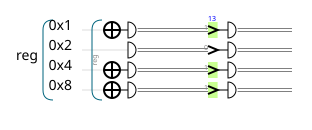

In [3]:
from psiqdk.workbench import QPU, QUInt

qpu = QPU(num_qubits=4)
reg = QUInt(4, "reg", qpu)

# Encode an unsigned integer 13 bit by bit
reg[0].x()
reg[2:].x()
print(reg.read())
qpu.nop(repeat=3)

# Write an unsigned integer
reg.write(13)
print(reg.read())
qpu.nop(repeat=3)

qpu.draw()

Another example of interpreting a value storied in a quantum register as a number is applying controlled operations with different quantum conditions.
[Controlled gates with simple control patterns](../tutorials/Controlled-Gates.ipynb#applying-controlled-gates-with-different-control-patterns) and
[gates conditioned on comparison results](../tutorials/Qubricks-Computed-Context-Manager.ipynb#using-comparisons-with-context-manager) both rely on comparing the value of the control register with a number, which requires thinking about this value itself as a number.

The following code snippet illustrates several such conditions.

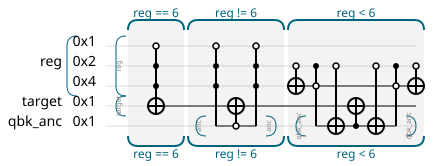

In [4]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=5)
reg = Qubits(3, "reg", qpu)
target = Qubits(1, "target", qpu)

qpu.label("reg == 6")
target.x(cond=reg == 6)

qpu.label("reg != 6")
with reg != 6 as cond:
    target.x(cond)

qpu.label("reg < 6")
with reg < 6 as cond:
    target.x(cond)

qpu.draw()

### Lists of basis states

The next example comes up when you handle information about the quantum state that is linked to the basis states that are included in this state. Typically, this is the list of amplitudes or probabilities of the basis states. APIs used for [testing and debugging](../tutorials/Testing-Debugging.ipynb) often use or return information in such a format:

* `pull_state()` method of Qubits and QPU objects returns the quantum state as a list of amplitudes.
* `push_state()` method initializes the state of a Qubits or QPU object to the quantum state given as a list of amplitudes.
* Workbench Algorithms state preparation Qubricks take a list of amplitudes as an argument to their `compute` methods.

In such a list, the basis states themselves are encoded implicitly as the indices of list elements. This also relies on little-endian encoding.

> Other testing and debugging APIs make the values of the basis states in the information explicit. For example, the `print_state_vector()` and `print_probabilities()` methods print the values encoded in the basis states along with the amplitudes/probabilities; `peek_n_biggest_terms()` returns the list of basis states (as integers in little-endian encoding) along with the list of their amplitudes, and so on.

The following code snippet shows a simple test you can use whenever you're working with a new toolkit and want to check whether it uses big-endian or little-endian encoding for lists of basis states. It prepares the basis state $|10\rangle$ (first qubit in state $|1\rangle$, second qubit in state $|0\rangle$) and fetches the list of amplitudes of the system. Toolkits that use little-endian encoding, including Workbench, will return `[0, 1, 0, 0]` (this basis state corresponds to $1$). Toolkits that use big-endian encoding will return `[0, 0, 1, 0]`.

In [5]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=2)
reg = Qubits(2, "reg", qpu)

reg[0].x()

print(qpu.pull_state().real)

[0. 1. 0. 0.]


### Unitary matrices

A similar but less common example involves representing operations as unitary matrices, either for [testing the routine implementation](../tutorials/Testing-Debugging.ipynb#getting-the-matrix-of-a-unitary) or for [injecting an arbitrary matrix](../tutorials/Built-in-Qubricks.ipynb#applying-a-unitary-described-as-a-matrix) into a program without breaking it down into primitive gates.

Same as in the case of lists of basis states, the encoding of basis states as integers impacts their mapping to the columns and rows of the matrix. If you don't take it into account, the results you get might look quite unexpected!

The following example shows another quick test for the endianness used by the toolkit: getting the matrix of the CNOT gate with the first qubit acting as the control and the second qubit - as the target. The matrix you see in the literature looks as follows: 

\begin{matrix}
1 & 0 & 0 & 0 \\ 
0 & 1 & 0 & 0 \\ 
0 & 0 & 0 & 1 \\ 
0 & 0 & 1 & 0 
\end{matrix}

This corresponds to big-endian notation for labeling rows and columns: the basis states $0$ and $1$ with the first (most significant) bit $0$ remain unchanged. The use of little-endian notation in Workbench changes the matrix: the first qubit corresponds to the least significant bit, so the basis states $0$ and $2$ remain unchanged.

In [6]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=2, filters=[">>unitary>>"])
reg = Qubits(2, "reg", qpu)

reg[1].x(cond=reg[0])

ufilter = qpu.get_filter_by_name('>>unitary>>')
matrix = ufilter.get()

print(matrix.real)

[[1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]]


### Specifying a subset of qubits using a bitmask

Finally, we'll switch gears and take a look at mask-based indexing of qubits, that is, using integers that encode subsets of qubit registers instead of the values stored in them. The most prominent application of bitmasks in Workbench is applying operations to subsets of qubits. For example, [Pauli product rotations](../tutorials/Advanced-Gates.ipynb#pauli-product-rotations) and [measurements](../tutorials/Advanced-Gates.ipynb#pauli-product-measurements) use two bitmasks to specify the Pauli gates that should be applied to each qubit of a register.

The same little-endian encoding is used in this scenario: the least significant bit corresponds to qubit with index $0$.

For examples of using bitmasks with Pauli product rotations and measurements, see the [Non-standard Gates and Measurements tutorial](../tutorials/Advanced-Gates.ipynb).